In [28]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)


Running on: cpu


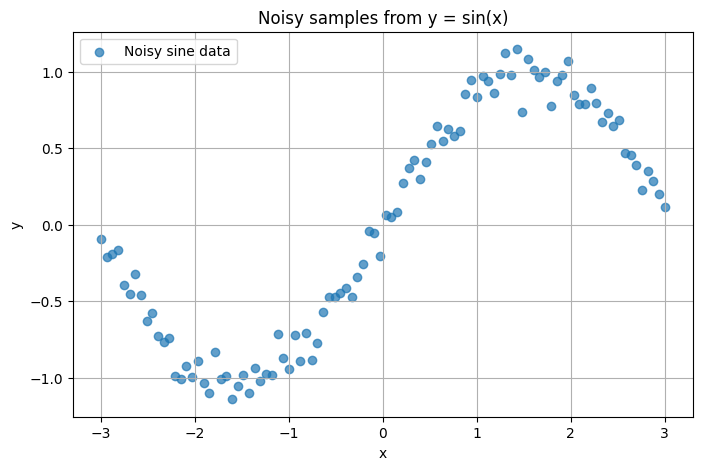

Step  20 | Loss: 0.2600 | w: 0.2032 | b: -0.0315
Step  40 | Loss: 0.2008 | w: 0.3006 | b: -0.0245
Step  60 | Loss: 0.1960 | w: 0.3282 | b: -0.0198
Step  80 | Loss: 0.1955 | w: 0.3360 | b: -0.0167
Step 100 | Loss: 0.1955 | w: 0.3382 | b: -0.0146
Step 120 | Loss: 0.1955 | w: 0.3388 | b: -0.0132
Step 140 | Loss: 0.1955 | w: 0.3390 | b: -0.0123
Step 160 | Loss: 0.1955 | w: 0.3390 | b: -0.0116
Step 180 | Loss: 0.1955 | w: 0.3390 | b: -0.0112
Step 200 | Loss: 0.1955 | w: 0.3390 | b: -0.0109


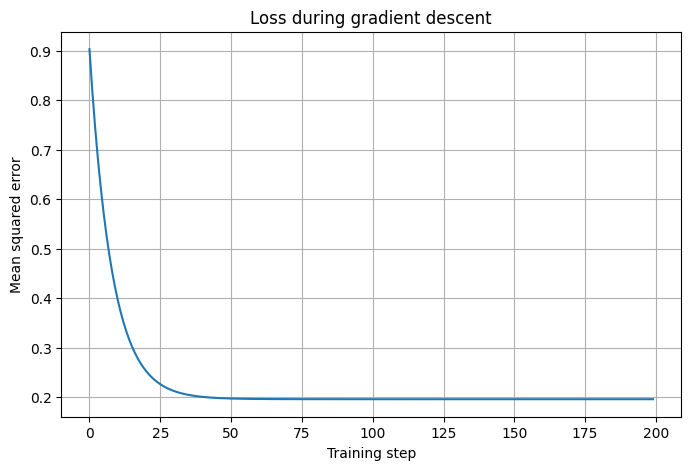

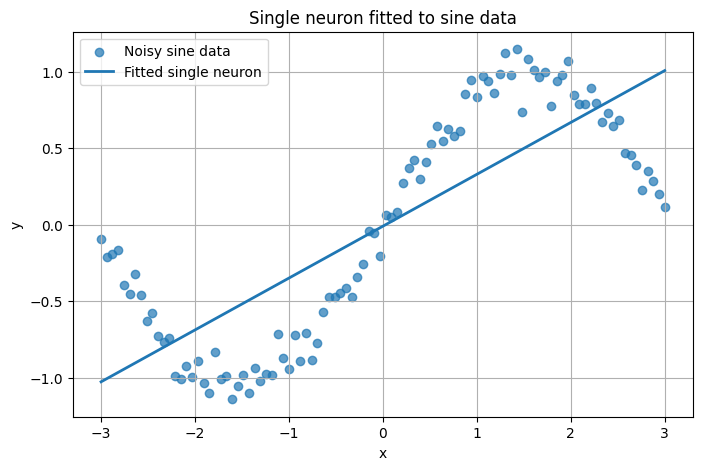

Final weight: 0.3390312757270389
Final bias: -0.010941835786772039
Final loss: 0.19545212040311394


In [29]:
# Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Plot the data
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Noisy sine data", alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy samples from y = sin(x)")
plt.legend()
plt.grid(True)
plt.show()

# Initialise parameters
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

# Training settings
lr = 0.01
steps = 200
losses = []

# Gradient-descent loop
for step in range(steps):
    # Forward pass
    y_hat = w * x + b

    # Loss
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Parameter updates
    w -= lr * dw
    b -= lr * db

    if (step + 1) % 20 == 0:
        print(
            f"Step {step + 1:3d} | "
            f"Loss: {loss:.4f} | "
            f"w: {w:.4f} | "
            f"b: {b:.4f}"
        )

# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Mean squared error")
plt.title("Loss during gradient descent")
plt.grid(True)
plt.show()

# Final predictions
final_predictions = w * x + b

# Plot final fit
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label="Noisy sine data", alpha=0.7)
plt.plot(x, final_predictions, linewidth=2, label="Fitted single neuron")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single neuron fitted to sine data")
plt.legend()
plt.grid(True)
plt.show()

print("Final weight:", w)
print("Final bias:", b)
print("Final loss:", losses[-1])

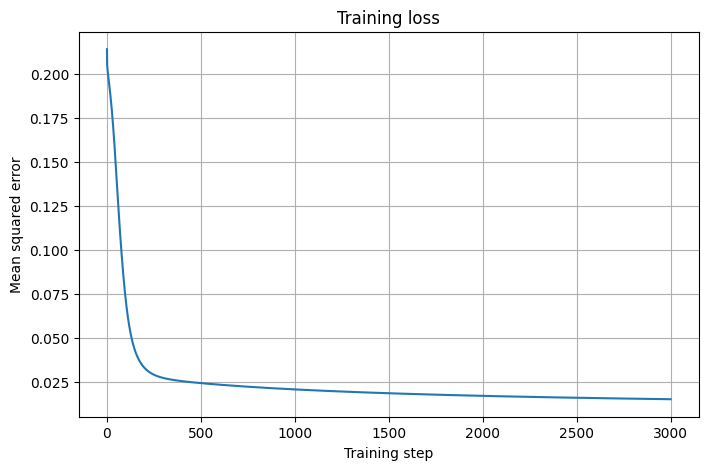

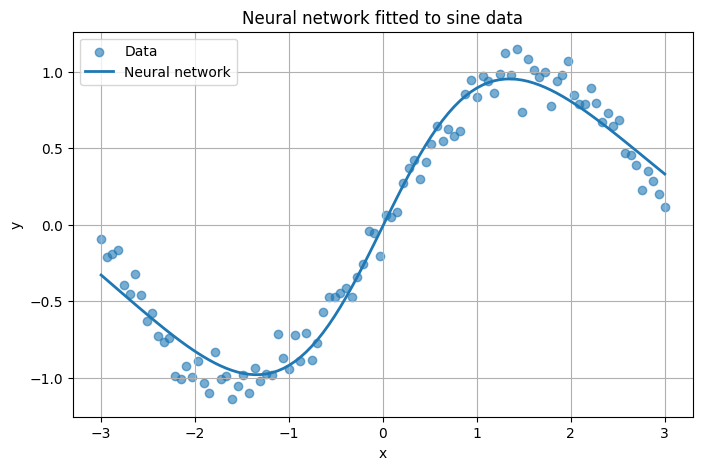

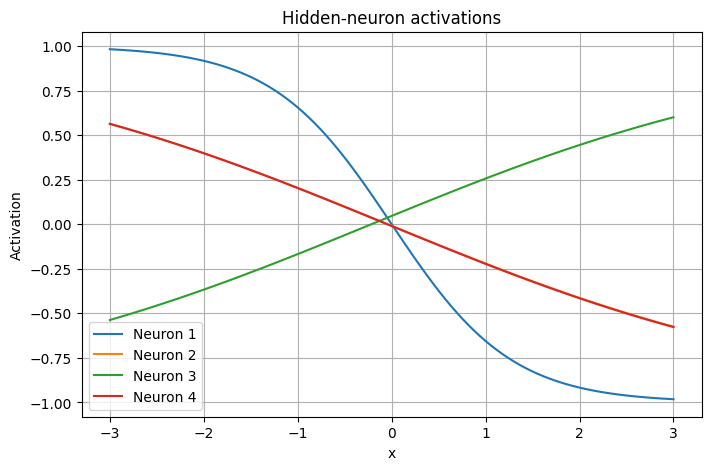

Initial loss: 0.2139124761878486
Final loss: 0.015062367966074358
Final prediction shape: (100, 1)


In [30]:
# Make results reproducible
np.random.seed(42)

# Generate data
x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)

# Training settings
lr = 0.05
steps = 3000
losses = []

# Training loop
for step in range(steps):

    # Forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    # Mean squared error
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradient of loss
    d_yhat = 2 * (y_hat - y) / len(y)

    # Output-layer gradients
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    # Pass gradient into hidden layer
    dh = d_yhat @ W2.T

    # Gradient through tanh
    dz1 = dh * (1 - h ** 2)

    # First-layer gradients
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Parameter updates
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2


# Plotting training loss
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Training step")
plt.ylabel("Mean squared error")
plt.title("Training loss")
plt.grid(True)
plt.show()


# Final forward pass using updated parameters
z1 = x @ W1 + b1
h = np.tanh(z1)
final_predictions = h @ W2 + b2


# Plotting final prediction
plt.figure(figsize=(8, 5))
plt.scatter(
    x.flatten(),
    y.flatten(),
    label="Data",
    alpha=0.6
)

plt.plot(
    x.flatten(),
    final_predictions.flatten(),
    label="Neural network",
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural network fitted to sine data")
plt.legend()
plt.grid(True)
plt.show()


# Plotting hidden-neuron activations
plt.figure(figsize=(8, 5))

for neuron in range(4):
    plt.plot(
        x.flatten(),
        h[:, neuron],
        label=f"Neuron {neuron + 1}"
    )

plt.xlabel("x")
plt.ylabel("Activation")
plt.title("Hidden-neuron activations")
plt.legend()
plt.grid(True)
plt.show()


# Displaying results
print("Initial loss:", losses[0])
print("Final loss:", losses[-1])
print("Final prediction shape:", final_predictions.shape)

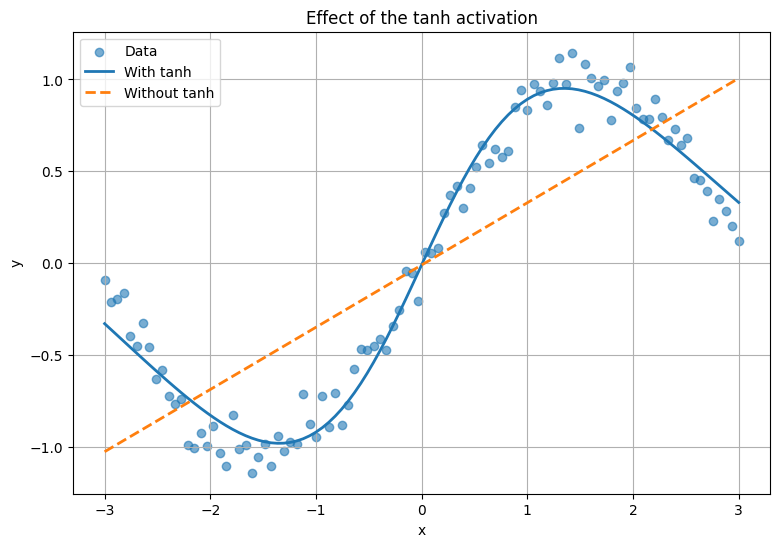

In [31]:
# Reset the seed
np.random.seed(42)

# Initialise separate parameters
W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.zeros(8)

W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.zeros(1)

linear_losses = []

for step in range(steps):

    # Forward pass without tanh
    z1_linear = x @ W1_linear + b1_linear
    h_linear = z1_linear
    y_hat_linear = h_linear @ W2_linear + b2_linear

    # Loss
    linear_loss = np.mean((y_hat_linear - y) ** 2)
    linear_losses.append(linear_loss)

    # Backward pass
    d_yhat_linear = 2 * (y_hat_linear - y) / len(y)

    dW2_linear = h_linear.T @ d_yhat_linear
    db2_linear = d_yhat_linear.sum(axis=0)

    dh_linear = d_yhat_linear @ W2_linear.T

    # No activation, so derivative is 1
    dz1_linear = dh_linear

    dW1_linear = x.T @ dz1_linear
    db1_linear = dz1_linear.sum(axis=0)

    # Update parameters
    W1_linear -= lr * dW1_linear
    b1_linear -= lr * db1_linear
    W2_linear -= lr * dW2_linear
    b2_linear -= lr * db2_linear

    z1_linear = x @ W1_linear + b1_linear
h_linear = z1_linear
linear_predictions = h_linear @ W2_linear + b2_linear

# Plotting the graph to compare with and without tanh

plt.figure(figsize=(9, 6))

plt.scatter(
    x.flatten(),
    y.flatten(),
    alpha=0.6,
    label="Data"
)

plt.plot(
    x.flatten(),
    final_predictions.flatten(),
    linewidth=2,
    label="With tanh"
)

plt.plot(
    x.flatten(),
    linear_predictions.flatten(),
    linestyle="--",
    linewidth=2,
    label="Without tanh"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of the tanh activation")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2369/3050143432.py:23: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_2369/3050143432.py:32: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_2369/3050143432.py:33: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - h ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


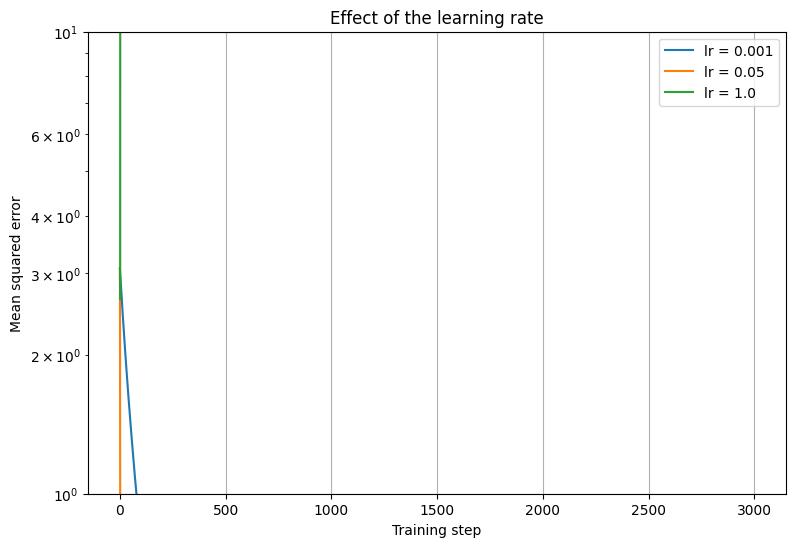

In [32]:
def train_toy(lr, steps=3000):

    # Reset seed so every learning rate starts
    # from the same parameters
    np.random.seed(42)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []

    for step in range(steps):

        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        # Loss
        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - h ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Updates
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

losses_slow = train_toy(lr=0.001)
losses_good = train_toy(lr=0.05)
losses_large = train_toy(lr=1.0)

plt.figure(figsize=(9, 6))

plt.plot(losses_slow, label="lr = 0.001")
plt.plot(losses_good, label="lr = 0.05")
plt.plot(losses_large, label="lr = 1.0")

plt.xlabel("Training step")
plt.ylabel("Mean squared error")
plt.title("Effect of the learning rate")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
import numpy as np
import pandas as pd
import torch

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


# Dataset URL reused from Lab 2
OBESITY_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "GkDzb7bWrtvGXdPOfk6CIg/"
    "Obesity-level-prediction-dataset.csv"
)


# Load the dataset
obesity = pd.read_csv(OBESITY_URL)

print("Original dataset shape:", obesity.shape)
display(obesity.head())


# Make a working copy
obesity_clean = obesity.copy()

# Remove missing observations
obesity_clean = obesity_clean.dropna()


# Feature engineering reused from Lab 2
obesity_clean["BMI"] = (
    obesity_clean["Weight"] /
    (obesity_clean["Height"] ** 2)
)


# Encode the target
target_encoder = LabelEncoder()

obesity_clean["NObeyesdad_encoded"] = (
    target_encoder.fit_transform(
        obesity_clean["NObeyesdad"]
    )
)


# Separate target
y_obesity = obesity_clean["NObeyesdad_encoded"]


# Separate features
X_obesity = obesity_clean.drop(
    columns=[
        "NObeyesdad",
        "NObeyesdad_encoded"
    ]
)


# One-hot encode categorical features
X_obesity_encoded = pd.get_dummies(
    X_obesity,
    drop_first=True
)


# First split: 80% temporary training, 20% test
X_temp_obesity, X_test_obesity, y_temp_obesity, y_test_obesity = (
    train_test_split(
        X_obesity_encoded,
        y_obesity,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_obesity
    )
)


# Second split: 75% of temporary set becomes training
# and 25% becomes validation
X_train_obesity, X_val_obesity, y_train_obesity, y_val_obesity = (
    train_test_split(
        X_temp_obesity,
        y_temp_obesity,
        test_size=0.25,
        random_state=RANDOM_STATE,
        stratify=y_temp_obesity
    )
)


# Scale the features
scaler_obesity = StandardScaler()

X_train_obesity_scaled = scaler_obesity.fit_transform(
    X_train_obesity
)

X_val_obesity_scaled = scaler_obesity.transform(
    X_val_obesity
)

X_test_obesity_scaled = scaler_obesity.transform(
    X_test_obesity
)


# Convert feature arrays to float32 tensors
X_train_tensor = torch.tensor(
    X_train_obesity_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_obesity_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_obesity_scaled,
    dtype=torch.float32
)


# Convert target arrays to long tensors
y_train_tensor = torch.tensor(
    y_train_obesity.to_numpy(),
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val_obesity.to_numpy(),
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test_obesity.to_numpy(),
    dtype=torch.long
)


# Create TensorDatasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# Check the results
print("\nEncoded feature shape:", X_obesity_encoded.shape)

print("\nTensor shapes:")
print("Training:", X_train_tensor.shape, y_train_tensor.shape)
print("Validation:", X_val_tensor.shape, y_val_tensor.shape)
print("Test:", X_test_tensor.shape, y_test_tensor.shape)

print("\nFeature dtype:", X_train_tensor.dtype)
print("Target dtype:", y_train_tensor.dtype)

print("\nNumber of input features:", X_train_tensor.shape[1])
print("Number of classes:", len(target_encoder.classes_))

print("\nEncoded target classes:")
for number, class_name in enumerate(target_encoder.classes_):
    print(number, "=", class_name)

Original dataset shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Encoded feature shape: (2111, 24)

Tensor shapes:
Training: torch.Size([1266, 24]) torch.Size([1266])
Validation: torch.Size([422, 24]) torch.Size([422])
Test: torch.Size([423, 24]) torch.Size([423])

Feature dtype: torch.float32
Target dtype: torch.int64

Number of input features: 24
Number of classes: 7

Encoded target classes:
0 = Insufficient_Weight
1 = Normal_Weight
2 = Obesity_Type_I
3 = Obesity_Type_II
4 = Obesity_Type_III
5 = Overweight_Level_I
6 = Overweight_Level_II


In [34]:
import torch
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_tensor.shape[1]
n_classes = len(target_encoder.classes_)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=(64, 32),
    n_classes=n_classes
)

model = model.to(DEVICE)

print("Device:", DEVICE)
print(model)

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(DEVICE)

logits = model(X_batch)

print("Input shape:", X_batch.shape)
print("Output shape:", logits.shape)
print("Target shape:", y_batch.shape)

Device: cpu
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Input shape: torch.Size([32, 24])
Output shape: torch.Size([32, 7])
Target shape: torch.Size([32])


Epoch 01/50 | Train Loss: 1.7140 | Train Accuracy: 0.4573 | Val Loss: 1.7205 | Val Accuracy: 0.4573
Epoch 02/50 | Train Loss: 1.2874 | Train Accuracy: 0.6027 | Val Loss: 1.2982 | Val Accuracy: 0.6114
Epoch 03/50 | Train Loss: 0.9614 | Train Accuracy: 0.6540 | Val Loss: 0.9805 | Val Accuracy: 0.6374
Epoch 04/50 | Train Loss: 0.7456 | Train Accuracy: 0.7725 | Val Loss: 0.7780 | Val Accuracy: 0.7701
Epoch 05/50 | Train Loss: 0.6052 | Train Accuracy: 0.8167 | Val Loss: 0.6501 | Val Accuracy: 0.8057
Epoch 06/50 | Train Loss: 0.5003 | Train Accuracy: 0.8618 | Val Loss: 0.5551 | Val Accuracy: 0.8294
Epoch 07/50 | Train Loss: 0.4176 | Train Accuracy: 0.8847 | Val Loss: 0.4849 | Val Accuracy: 0.8436
Epoch 08/50 | Train Loss: 0.3570 | Train Accuracy: 0.8949 | Val Loss: 0.4327 | Val Accuracy: 0.8531
Epoch 09/50 | Train Loss: 0.3031 | Train Accuracy: 0.9242 | Val Loss: 0.3852 | Val Accuracy: 0.8744
Epoch 10/50 | Train Loss: 0.2593 | Train Accuracy: 0.9400 | Val Loss: 0.3464 | Val Accuracy: 0.9076


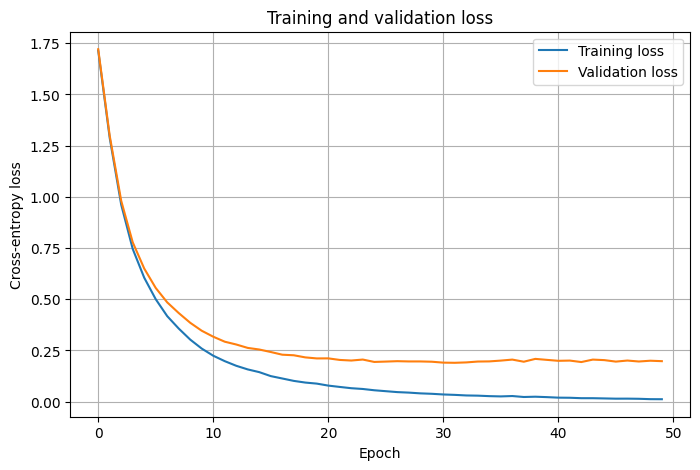

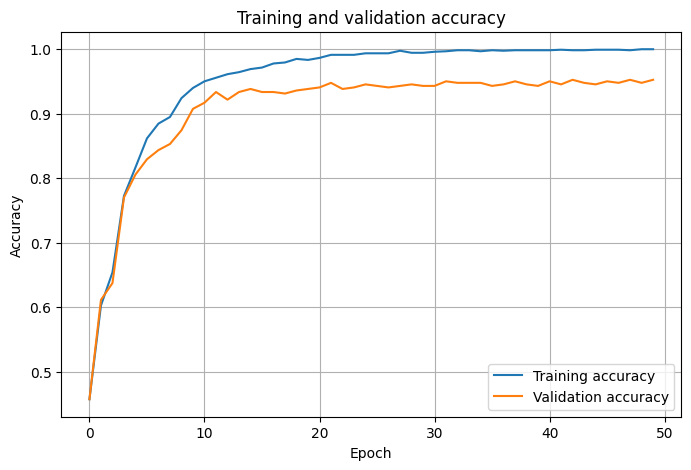

Best validation accuracy: 0.95260663507109


In [35]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


def evaluate_model(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            batch_size = xb.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (
                predictions == yb
            ).sum().item()

            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy


EPOCHS = 50

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0


for epoch in range(EPOCHS):

    model.train()

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

    train_loss, train_accuracy = evaluate_model(
        model,
        train_loader,
        criterion
    )

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "ffn_best.pt"
        )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )


# Plot loss curves
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Training loss"
)

plt.plot(
    history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()


# Plot accuracy curves
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Training accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()


print(
    "Best validation accuracy:",
    best_val_accuracy
)

In [36]:
class FeedForwardNet(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_sizes=(64, 32),
        n_classes=7,
        dropout=0.0
    ):
        super().__init__()

        layers = []
        current_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(
                nn.Linear(current_dim, hidden_dim)
            )
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(
                    nn.Dropout(dropout)
                )

            current_dim = hidden_dim

        layers.append(
            nn.Linear(current_dim, n_classes)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


In [37]:
import time

def run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
):
    # Reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    # Create a fresh training loader
    experiment_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Create a fresh model
    experiment_model = FeedForwardNet(
        input_dim=input_dim,
        hidden_sizes=hidden_sizes,
        n_classes=n_classes,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        experiment_model.parameters(),
        lr=lr
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_accuracy = 0.0
    best_state = None

    start_time = time.time()

    for epoch in range(epochs):
        experiment_model.train()

        for xb, yb in experiment_train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = experiment_model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

        train_loss, train_accuracy = evaluate_model(
            experiment_model,
            experiment_train_loader,
            criterion
        )

        val_loss, val_accuracy = evaluate_model(
            experiment_model,
            val_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy

            best_state = {
                name: value.detach().cpu().clone()
                for name, value
                in experiment_model.state_dict().items()
            }

    training_time = time.time() - start_time

    return {
        "model": experiment_model,
        "history": history,
        "best_state": best_state,
        "best_val_accuracy": best_val_accuracy,
        "training_time": training_time
    }

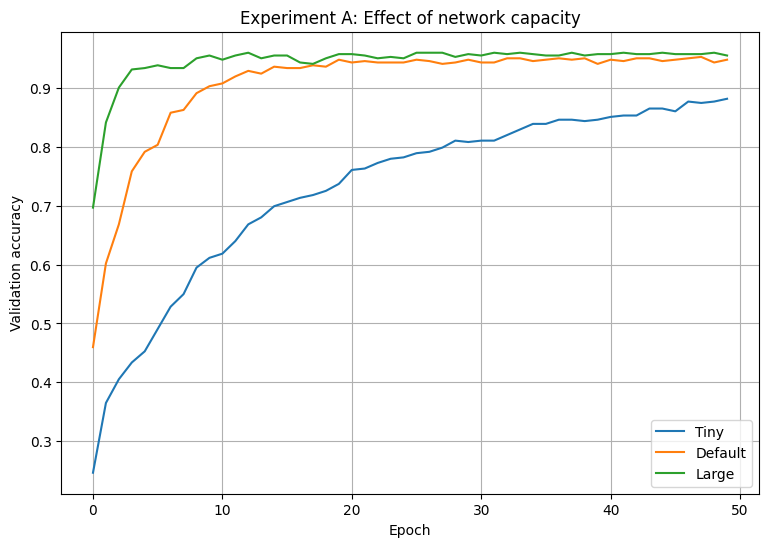

Tiny: 0.8815
Default: 0.9526
Large: 0.9597


In [40]:
#Experiment A
capacity_results = {}

capacity_results["Tiny"] = run_experiment(
    hidden_sizes=(8,),
    lr=1e-3,
    batch_size=32,
    epochs=50
)

capacity_results["Default"] = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50
)

capacity_results["Large"] = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50
)

plt.figure(figsize=(9, 6))

for name, result in capacity_results.items():
    plt.plot(
        result["history"]["val_accuracy"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Experiment A: Effect of network capacity")
plt.legend()
plt.grid(True)
plt.show()

for name, result in capacity_results.items():
    print(
        f"{name}: "
        f"{result['best_val_accuracy']:.4f}"
    )

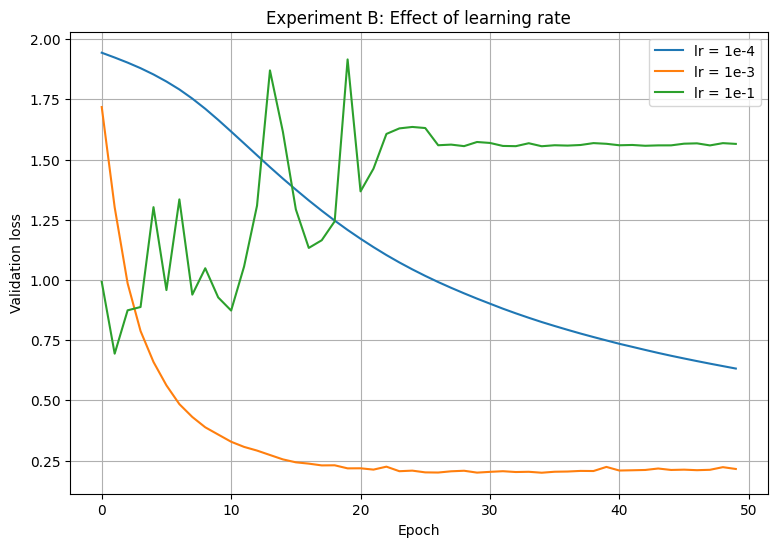

In [41]:
# Experiment B
learning_rate_results = {}

learning_rate_results["lr = 1e-4"] = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-4,
    batch_size=32,
    epochs=50
)

learning_rate_results["lr = 1e-3"] = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-3,
    batch_size=32,
    epochs=50
)

learning_rate_results["lr = 1e-1"] = run_experiment(
    hidden_sizes=(64, 32),
    lr=1e-1,
    batch_size=32,
    epochs=50
)

plt.figure(figsize=(9, 6))

for name, result in learning_rate_results.items():
    plt.plot(
        result["history"]["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Experiment B: Effect of learning rate")
plt.legend()
plt.grid(True)
plt.show()

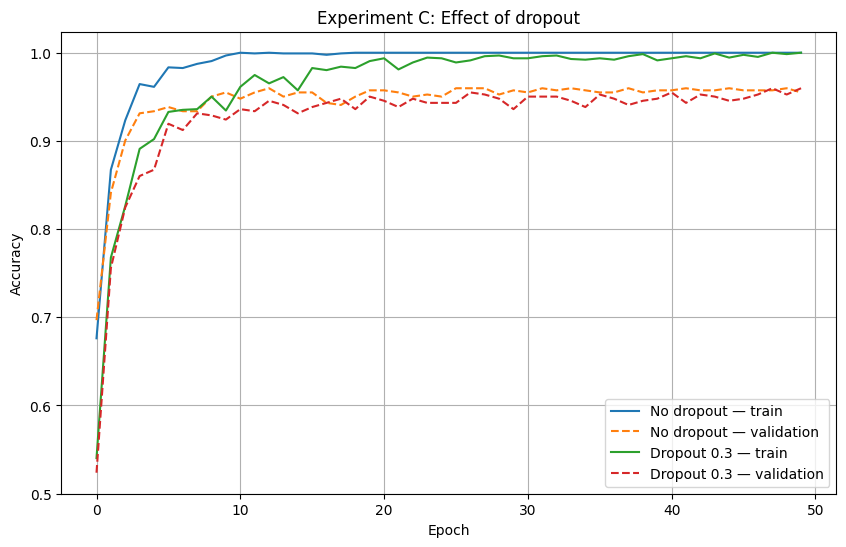

In [42]:
# Experiment C
dropout_results = {}

dropout_results["No dropout"] = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.0
)

dropout_results["Dropout 0.3"] = run_experiment(
    hidden_sizes=(256, 128, 64),
    lr=1e-3,
    batch_size=32,
    epochs=50,
    dropout=0.3
)

plt.figure(figsize=(10, 6))

for name, result in dropout_results.items():
    history = result["history"]

    plt.plot(
        history["train_accuracy"],
        label=f"{name} — train"
    )

    plt.plot(
        history["val_accuracy"],
        linestyle="--",
        label=f"{name} — validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Effect of dropout")
plt.legend()
plt.grid(True)
plt.show()

Test accuracy: 0.9409
Test macro-F1: 0.9397

Classification Report
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.96        54
      Normal_Weight       0.88      0.86      0.87        58
     Obesity_Type_I       0.93      0.97      0.95        70
    Obesity_Type_II       0.98      0.93      0.96        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.90      0.90        58
Overweight_Level_II       0.95      0.93      0.94        58

           accuracy                           0.94       423
          macro avg       0.94      0.94      0.94       423
       weighted avg       0.94      0.94      0.94       423



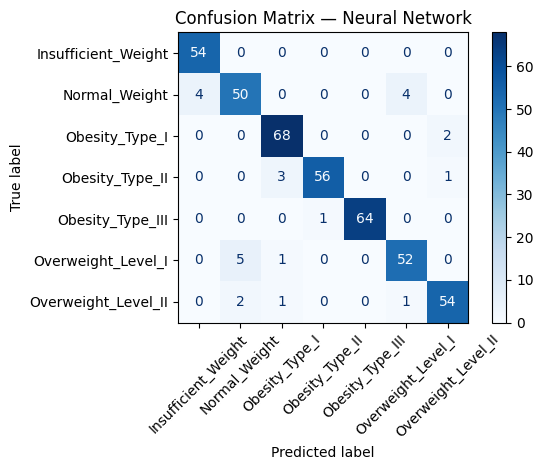

,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters / Trees
0,Random Forest — Lab 2,0.979000,0.978000,Not recorded,100 trees
1,Feedforward Neural Network,0.940898,0.939699,3.94 seconds,"3,911 parameters"


In [43]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Enter the best configuration from Experiments A–C
best_hidden_sizes = (64, 32)
best_lr = 1e-3
best_dropout = 0.0

# Train the selected configuration
best_result = run_experiment(
    hidden_sizes=best_hidden_sizes,
    lr=best_lr,
    batch_size=32,
    epochs=50,
    dropout=best_dropout
)

# Recreate the model
best_model = FeedForwardNet(
    input_dim=input_dim,
    hidden_sizes=best_hidden_sizes,
    n_classes=n_classes,
    dropout=best_dropout
).to(DEVICE)

# Load its best validation weights
best_model.load_state_dict(best_result["best_state"])
best_model.eval()

# Make test predictions
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = best_model(xb)
        predictions = torch.argmax(logits, dim=1)

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_targets.extend(
            yb.cpu().numpy()
        )

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

# Test metrics
nn_test_accuracy = accuracy_score(
    all_test_targets,
    all_test_predictions
)

nn_test_macro_f1 = f1_score(
    all_test_targets,
    all_test_predictions,
    average="macro"
)

print(f"Test accuracy: {nn_test_accuracy:.4f}")
print(f"Test macro-F1: {nn_test_macro_f1:.4f}")

# Classification report
print("\nClassification Report")
print(
    classification_report(
        all_test_targets,
        all_test_predictions,
        target_names=target_encoder.classes_
    )
)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    all_test_targets,
    all_test_predictions,
    display_labels=target_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix — Neural Network")
plt.tight_layout()
plt.show()

# Parameter count
nn_parameter_count = sum(
    parameter.numel()
    for parameter in best_model.parameters()
    if parameter.requires_grad
)

# Comparison with Lab 2
comparison_table = pd.DataFrame({
    "Model": [
        "Random Forest — Lab 2",
        "Feedforward Neural Network"
    ],
    "Test Accuracy": [
        0.979,
        nn_test_accuracy
    ],
    "Test Macro-F1": [
        0.978,
        nn_test_macro_f1
    ],
    "Training Time": [
        "Not recorded",
        f"{best_result['training_time']:.2f} seconds"
    ],
    "Parameters / Trees": [
        "100 trees",
        f"{nn_parameter_count:,} parameters"
    ]
})

display(comparison_table)